#Load and pick the columns

In [14]:
import pandas as pd #Data upload and data preparation
import numpy as np # Data calculs
import matplotlib.pyplot as plt # Visualization
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv' #url location
df=pd.read_csv(url) #Data frame upload url
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0) #Empty TotalCharges column fill in 0 value

#Pick the columns and look at the problem

In [15]:
cols = ['MonthlyCharges', 'TotalCharges'] # select 'MonthlyCharges', 'TotalCharges'
df[cols].describe().round(2) # describe 'MonthlyCharges', 'TotalCharges' columns value float poin than 2 values count	mean std min	25%	50%	75%	max

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,64.76,2279.73
std,30.09,2266.79
min,18.25,0.00
25%,35.50,398.55
50%,70.35,1394.55
75%,89.85,3786.60
max,118.75,8684.80


#Apply MinMaxScaler (squeeze to 0-1)

In [16]:
from sklearn.preprocessing import MinMaxScaler #import sclearn library MinMaxScaler
mm = MinMaxScaler()
X=df[cols] # Select column
X_mm = mm.fit_transform(X) # fit transform select column MinMaxScaler
X_mm_df = pd.DataFrame(X_mm, columns=cols) # df each elemnt lelect column MinMaxScaler
X_mm_df.agg(['min', 'max']).round(2) # min and max value MinMaxScaler

,MonthlyCharges,TotalCharges
min,0.0,0.0
max,1.0,1.0


#Apply StandardScaler

In [17]:
from sklearn.preprocessing import StandardScaler #import sclearn library StandardScaler
std = StandardScaler()
X_std = std.fit_transform(X) # fit transform select column StandardScaler
X_std_df = pd.DataFrame(X_std, columns=cols) # df each elemnt lelect column StandardScaler
X_std_df.describe().round(2) # describe df value

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.00,-0.00
std,1.00,1.00
min,-1.55,-1.01
25%,-0.97,-0.83
50%,0.19,-0.39
75%,0.83,0.66
max,1.79,2.83


#Apply RobustScaler


In [18]:
from sklearn.preprocessing import RobustScaler #import sclearn library RobustScaler
rb = RobustScaler()
X_rb = rb.fit_transform(X) # fit transform select column RobustScaler
X_rb_df = pd.DataFrame(X_rb, columns=cols) # df each elemnt lelect column RobustScaler
X_rb_df.describe().round(2) # describe df value

,MonthlyCharges,TotalCharges
count,7043.00,7043.00
mean,-0.10,0.26
std,0.55,0.67
min,-0.96,-0.41
25%,-0.64,-0.29
50%,0.00,0.00
75%,0.36,0.71
max,0.89,2.15


#Compare distributions with histograms

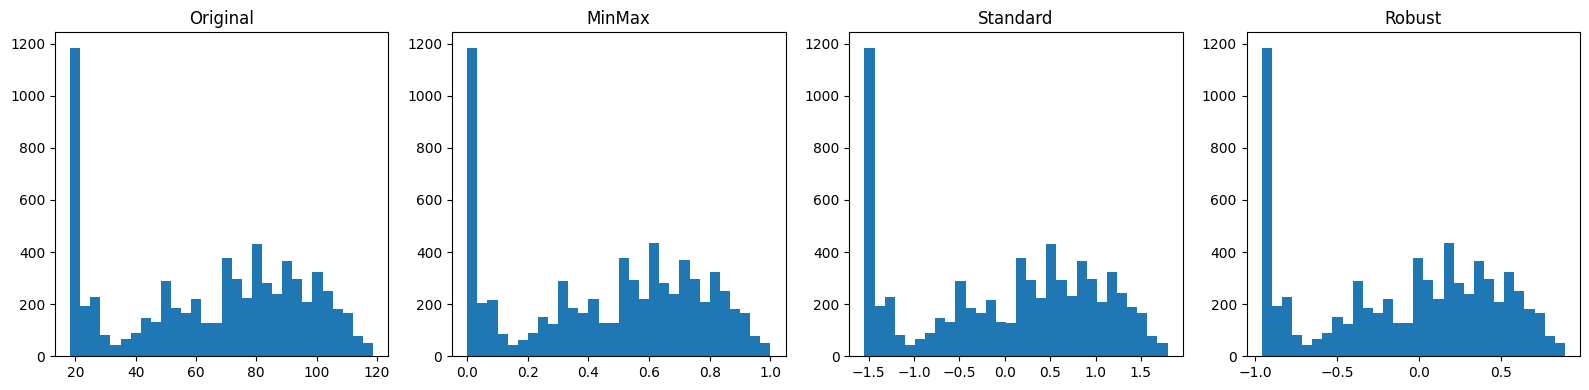

In [19]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4)) # subplots [1, 4]
ax[0].hist(df['MonthlyCharges'], bins=30); ax[0].set_title('Original') # Original values hist
ax[1].hist(X_mm_df['MonthlyCharges'], bins=30); ax[1].set_title('MinMax') #MinMax values hist
ax[2].hist(X_std_df['MonthlyCharges'], bins=30); ax[2].set_title('Standard') #Standard values hist
ax[3].hist(X_rb_df['MonthlyCharges'], bins=30); ax[3].set_title('Robust') #Standard values hist
plt.tight_layout() #This function automatically adjusts the padding between and around my subplots
plt.show()

#The leakage rule: split FIRST, scale SECOND

In [20]:
from sklearn.model_selection import train_test_split # #import sclearn library for data train and test splits
X_train, X_test = train_test_split(X, test_size = 0.2, random_state=42) #fragmentation data train 80% , test 20%
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # give fit transform train data
X_test_s = scaler.transform(X_test) # give transform test data
print('Train mean:', X_train_s.mean(axis=0).round(2))
print('Test mean:', X_test_s.mean(axis=0).round(2))

Train mean: [-0.  0.]
Test mean: [-0.02 -0.02]
